<a href="https://colab.research.google.com/github/irostylemina/gitstudy/blob/main/%EC%9E%84%EB%AF%B8%EB%82%98_2025163046_%EA%B8%B0%EB%A7%90%EA%B3%BC%EC%A0%9C.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#라이브러리 불러오기

In [1]:
# 데이터 분석에 필요한 라이브러리 불러오기
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

#데이터 불러오기

In [2]:
# 2023년, 2025년 따릉이 대여소별 이용정보 CSV 파일 불러오기
df23 = pd.read_csv("서울특별시 공공자전거 대여소별 이용정보(월별)_23.1-12.csv", encoding="cp949")
df25 = pd.read_csv("서울특별시 공공자전거 대여소별 이용정보(월별)_25.1-12.csv", encoding="utf-8-sig")

# 데이터 앞부분 확인
display(df23.head())
display(df25.head())

,자치구,대여소명,기준년월,대여건수,반납건수
0,강남구,2301. 현대고등학교 건너편,202301,383,439
1,강남구,2302. 교보타워 버스정류장(신논현역 3번출구 후면),202301,433,446
2,강남구,2303. 논현역 10번출구,202301,648,508
3,강남구,2304. 대현그린타워,202301,76,55
4,강남구,2305. MCM 본사 직영점 앞,202301,172,179


,자치구,대여소명,기준년월,대여건수,반납건수
0,마포구,108. 서교동 사거리,202501,670,786
1,양천구,729. 서부식자재마트 건너편,202501,961,939
2,양천구,731. 서울시 도로환경관리센터,202501,1671,1722
3,양천구,733. 신정이펜하우스314동,202501,299,154
4,양천구,734. 신트리공원 입구,202501,1555,1549


#데이터확인

In [3]:
# 데이터 크기 확인
print("2023년 데이터 크기:", df23.shape)
print("2025년 데이터 크기:", df25.shape)

# 컬럼 확인
print("2023년 컬럼:", df23.columns)
print("2025년 컬럼:", df25.columns)

# 데이터 정보 확인
df23.info()
df25.info()

2023년 데이터 크기: (32687, 5)
2025년 데이터 크기: (32975, 5)
2023년 컬럼: Index(['자치구', '대여소명', '기준년월', '대여건수', '반납건수'], dtype='object')
2025년 컬럼: Index(['자치구', '대여소명', '기준년월', '대여건수', '반납건수'], dtype='object')
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32687 entries, 0 to 32686
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   자치구     32687 non-null  object
 1   대여소명    32687 non-null  object
 2   기준년월    32687 non-null  int64 
 3   대여건수    32687 non-null  object
 4   반납건수    32687 non-null  object
dtypes: int64(1), object(4)
memory usage: 1.2+ MB
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32975 entries, 0 to 32974
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   자치구     32975 non-null  object
 1   대여소명    32975 non-null  object
 2   기준년월    32975 non-null  int64 
 3   대여건수    32975 non-null  int64 
 4   반납건수    32975 non-null  int64 
dtypes: int64(3), object(2)
memory

#데이터 전처리

In [14]:
# 결측치 확인
print("2023년 결측치")
print(df23.isnull().sum())

print("\n2025년 결측치")
print(df25.isnull().sum())

# 중복 데이터 제거
df23 = df23.drop_duplicates()
df25 = df25.drop_duplicates()

# 대여건수, 반납건수를 숫자형으로 변환
df23["대여건수"] = pd.to_numeric(df23["대여건수"].astype(str).str.replace(",", ""), errors="coerce")
df25["대여건수"] = pd.to_numeric(df25["대여건수"].astype(str).str.replace(",", ""), errors="coerce")

df23["반납건수"] = pd.to_numeric(df23["반납건수"].astype(str).str.replace(",", ""), errors="coerce")
df25["반납건수"] = pd.to_numeric(df25["반납건수"].astype(str).str.replace(",", ""), errors="coerce")

# 전처리 후 확인
display(df23.head())
display(df25.head())

2023년 결측치
자치구     0
대여소명    0
기준년월    0
대여건수    0
반납건수    3
dtype: int64

2025년 결측치
자치구     0
대여소명    0
기준년월    0
대여건수    0
반납건수    0
dtype: int64


,자치구,대여소명,기준년월,대여건수,반납건수
0,강남구,2301. 현대고등학교 건너편,202301,383,439.0
1,강남구,2302. 교보타워 버스정류장(신논현역 3번출구 후면),202301,433,446.0
2,강남구,2303. 논현역 10번출구,202301,648,508.0
3,강남구,2304. 대현그린타워,202301,76,55.0
4,강남구,2305. MCM 본사 직영점 앞,202301,172,179.0


,자치구,대여소명,기준년월,대여건수,반납건수
0,마포구,108. 서교동 사거리,202501,670,786
1,양천구,729. 서부식자재마트 건너편,202501,961,939
2,양천구,731. 서울시 도로환경관리센터,202501,1671,1722
3,양천구,733. 신정이펜하우스314동,202501,299,154
4,양천구,734. 신트리공원 입구,202501,1555,1549


#성수동·서울숲 지역 데이터 추출

In [15]:
# 성수동·서울숲 지역과 관련된 키워드 설정
keywords = ["성수", "서울숲", "뚝섬"]
pattern = "|".join(keywords)

# 대여소명에 키워드가 포함된 데이터만 추출
seongsu23 = df23[df23["대여소명"].str.contains(pattern, na=False)].copy()
seongsu25 = df25[df25["대여소명"].str.contains(pattern, na=False)].copy()

print("2023년 성수권역 데이터 수:", len(seongsu23))
print("2025년 성수권역 데이터 수:", len(seongsu25))

display(seongsu23.head())
display(seongsu25.head())

2023년 성수권역 데이터 수: 252
2025년 성수권역 데이터 수: 226


,자치구,대여소명,기준년월,대여건수,반납건수
668,광진구,502. 뚝섬유원지역 1번출구 앞,202301,3093,3223.0
691,광진구,588. 뚝섬 유원지역,202301,939,908.0
1594,성동구,3515. 서울숲 관리사무소,202301,387,335.0
1600,성동구,3538. 서울숲 IT캐슬,202301,13,13.0
1604,성동구,3548.뚝섬역 6번출구,202301,1028,958.0


,자치구,대여소명,기준년월,대여건수,반납건수
43,성동구,508. 성수아카데미타워 앞,202501,3050,2780
67,성동구,511. 서울숲역 5번 출구 옆,202501,510,520
77,성동구,512. 뚝섬역 1번 출구 옆,202501,1163,1247
95,성동구,513. 뚝섬역 5번 출구 정류소 옆,202501,666,657
101,성동구,514. 성수사거리 버스정류장 앞,202501,1524,1569


#총 대여건수 비교

In [16]:
# 2023년과 2025년 총 대여건수 계산
total23 = seongsu23["대여건수"].sum()
total25 = seongsu25["대여건수"].sum()

change = total25 - total23
change_rate = (change / total23) * 100

print("2023년 성수권역 총 대여건수:", total23)
print("2025년 성수권역 총 대여건수:", total25)
print("증감:", change)
print("증감률:", round(change_rate, 2), "%")

2023년 성수권역 총 대여건수: 645015
2025년 성수권역 총 대여건수: 496594
증감: -148421
증감률: -23.01 %


#연도별 TOP10 대여소

In [7]:
# 2023년 대여건수 상위 10개 대여소
top10_2023 = (
    seongsu23.groupby("대여소명")["대여건수"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

# 2025년 대여건수 상위 10개 대여소
top10_2025 = (
    seongsu25.groupby("대여소명")["대여건수"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

print("2023년 성수권역 TOP10 대여소")
display(top10_2023)

print("2025년 성수권역 TOP10 대여소")
display(top10_2025)

2023년 성수권역 TOP10 대여소


,대여건수
대여소명,
502. 뚝섬유원지역 1번출구 앞,133948
589. 성수역3번출구,65129
585. 성수2가1동 공영주차장 인근,55147
567. 성수역 2번출구 앞,52758
514. 성수사거리 버스정류장 앞,35315
512. 뚝섬역 1번 출구 옆,35173
588. 뚝섬 유원지역,29922
508. 성수아카데미타워 앞,27574
3515. 서울숲 관리사무소,27422


2025년 성수권역 TOP10 대여소


,대여건수
대여소명,
502. 자양(뚝섬한강공원)역 1번출구 앞,94996
508. 성수아카데미타워 앞,53440
585. 성수2가1동 공영주차장 인근,46412
589. 성수역3번출구,31167
514. 성수사거리 버스정류장 앞,29822
512. 뚝섬역 1번 출구 옆,28726
4373. 서울숲 지식산업센터,26060
3548.뚝섬역 6번출구,24403
5153.한강버스 뚝섬 선착장,22842


#신규 대여소 및 사라진 대여소

In [8]:
# 연도별 대여소 목록 만들기
station23 = set(seongsu23["대여소명"])
station25 = set(seongsu25["대여소명"])

# 2025년에 새롭게 등장한 대여소
new_station = station25 - station23

# 2023년에는 있었지만 2025년에 사라진 대여소
removed_station = station23 - station25

print("2025년에 새로 등장한 대여소 수:", len(new_station))
print(new_station)

print("\n2025년에 사라진 대여소 수:", len(removed_station))
print(removed_station)

2025년에 새로 등장한 대여소 수: 3
{'5153.한강버스 뚝섬 선착장', '4401.뚝섬유수지 공영주차장', '502. 자양(뚝섬한강공원)역 1번출구 앞'}

2025년에 사라진 대여소 수: 5
{'502. 뚝섬유원지역 1번출구 앞', '3538. 서울숲 IT캐슬', '4370. 서울숲IT캐슬 앞', '510. 서울숲 남문 버스정류소 옆', '567. 성수역 2번출구 앞'}


#대여소별 증감 분석

In [9]:
# 대여소별 대여건수 집계
sum23 = seongsu23.groupby("대여소명")["대여건수"].sum()
sum25 = seongsu25.groupby("대여소명")["대여건수"].sum()

# 두 연도 데이터를 하나로 합치기
compare = pd.merge(
    sum23.rename("대여건수_2023"),
    sum25.rename("대여건수_2025"),
    left_index=True,
    right_index=True,
    how="outer"
).fillna(0)

# 증감과 증감률 계산
compare["증감"] = compare["대여건수_2025"] - compare["대여건수_2023"]
compare["증감률"] = np.where(
    compare["대여건수_2023"] > 0,
    compare["증감"] / compare["대여건수_2023"] * 100,
    np.nan
)

# 증가 TOP10
increase_top10 = compare.sort_values("증감", ascending=False).head(10)

# 감소 TOP10
decrease_top10 = compare.sort_values("증감").head(10)

print("이용량 증가 TOP10")
display(increase_top10)

print("이용량 감소 TOP10")
display(decrease_top10)

이용량 증가 TOP10


,대여건수_2023,대여건수_2025,증감,증감률
대여소명,,,,
502. 자양(뚝섬한강공원)역 1번출구 앞,0.0,94996.0,94996.0,NaN
508. 성수아카데미타워 앞,27574.0,53440.0,25866.0,93.805759
5153.한강버스 뚝섬 선착장,0.0,22842.0,22842.0,NaN
4387. 성수역 1번출구 주변,12104.0,19107.0,7003.0,57.856907
4401.뚝섬유수지 공영주차장,0.0,1869.0,1869.0,NaN
3538. 서울숲 IT캐슬,194.0,0.0,-194.0,-100.000000
4389. 서울숲역3번출구,4742.0,3975.0,-767.0,-16.174610
4373. 서울숲 지식산업센터,27061.0,26060.0,-1001.0,-3.699050
4360. 르노삼성자동차 성수사업소 앞,12164.0,10946.0,-1218.0,-10.013154


이용량 감소 TOP10


,대여건수_2023,대여건수_2025,증감,증감률
대여소명,,,,
502. 뚝섬유원지역 1번출구 앞,133948.0,0.0,-133948.0,-100.000000
567. 성수역 2번출구 앞,52758.0,0.0,-52758.0,-100.000000
589. 성수역3번출구,65129.0,31167.0,-33962.0,-52.145742
588. 뚝섬 유원지역,29922.0,21046.0,-8876.0,-29.663793
585. 성수2가1동 공영주차장 인근,55147.0,46412.0,-8735.0,-15.839484
511. 서울숲역 5번 출구 옆,21531.0,12841.0,-8690.0,-40.360411
510. 서울숲 남문 버스정류소 옆,7363.0,0.0,-7363.0,-100.000000
561. 서울숲역 2번출구 앞,25863.0,19322.0,-6541.0,-25.290956
512. 뚝섬역 1번 출구 옆,35173.0,28726.0,-6447.0,-18.329400


#시각화: 총 대여건수 비교 그래프

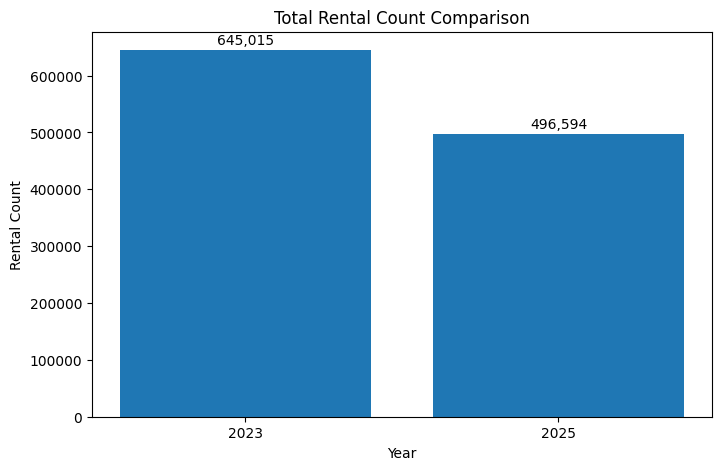

In [10]:
plt.figure(figsize=(8,5))

plt.bar(
    ["2023", "2025"],
    [total23, total25]
)

plt.title("Total Rental Count Comparison")
plt.xlabel("Year")
plt.ylabel("Rental Count")

# 값 표시
plt.text(0, total23 + 10000, f"{int(total23):,}", ha="center")
plt.text(1, total25 + 10000, f"{int(total25):,}", ha="center")

plt.show()

#최종결론

In [13]:
print("분석 결과 해석")
print("2023년 성수동·서울숲 지역 총 대여건수는", total23, "건입니다.")
print("2025년 성수동·서울숲 지역 총 대여건수는", total25, "건입니다.")
print("2023년 대비 2025년 증감률은", round(change_rate, 2), "%입니다.")
print("전체적으로 성수동·서울숲 지역의 따릉이 이용량은 감소하였지만,")
print("자양(뚝섬한강공원)역 1번출구 앞, 성수아카데미타워 앞, 한강버스 뚝섬 선착장 등 일부 대여소는 이용량이 증가하였습니다.")
print("이는 특정 대여소의 신설, 역명 변경, 한강공원 접근성 변화 등이 이용 패턴에 영향을 준 것으로 해석할 수 있습니다.")

분석 결과 해석
2023년 성수동·서울숲 지역 총 대여건수는 645015 건입니다.
2025년 성수동·서울숲 지역 총 대여건수는 496594 건입니다.
2023년 대비 2025년 증감률은 -23.01 %입니다.
전체적으로 성수동·서울숲 지역의 따릉이 이용량은 감소하였지만,
자양(뚝섬한강공원)역 1번출구 앞, 성수아카데미타워 앞, 한강버스 뚝섬 선착장 등 일부 대여소는 이용량이 증가하였습니다.
이는 특정 대여소의 신설, 역명 변경, 한강공원 접근성 변화 등이 이용 패턴에 영향을 준 것으로 해석할 수 있습니다.


#분석 결과

### ① 성수동·서울숲·뚝섬 권역에 해당하는 대여소 추출

본 과제에서는 대여소명에 ‘성수’, ‘서울숲’, ‘뚝섬’ 키워드가 포함된 대여소를 성수권역 대여소로 정의하였다.

추출 결과 2023년 데이터에서는 252개의 레코드가 추출되었고, 2025년 데이터에서는 226개의 레코드가 추출되었다.

---

### ② 2023년과 2025년 총 대여건수 비교

성수권역의 총 대여건수는 다음과 같이 나타났다.

* 2023년 : 645,015건
* 2025년 : 496,594건

따라서 2025년은 2023년에 비해 148,421건 감소하였으며, 증감률은 약 -23.01%로 나타났다.

---

### ③ 2023년과 2025년 이용량 상위 10개 대여소 비교

- 2023년 이용량 상위 10개 대여소는 다음과 같다.

1. 뚝섬유원지역 1번출구 앞 (133,948건)
2. 성수역3번출구 (65,129건)
3. 성수2가1동 공영주차장 인근 (55,147건)
4. 성수역 2번출구 앞 (52,758건)
5. 성수사거리 버스정류장 앞 (35,315건)
6. 뚝섬역 1번 출구 옆 (35,173건)
7. 뚝섬 유원지역 (29,922건)
8. 성수아카데미타워 앞 (27,574건)
9. 서울숲 관리사무소 (27,422건)
10. 서울숲 지식산업센터 (27,061건)

- 2025년 이용량 상위 10개 대여소는 다음과 같다.

1. 자양(뚝섬한강공원)역 1번출구 앞 (94,996건)
2. 성수아카데미타워 앞 (53,440건)
3. 성수2가1동 공영주차장 인근 (46,412건)
4. 성수역3번출구 (31,167건)
5. 성수사거리 버스정류장 앞 (29,822건)
6. 뚝섬역 1번 출구 옆 (28,726건)
7. 서울숲 지식산업센터 (26,060건)
8. 뚝섬역 6번출구 (24,403건)
9. 한강버스 뚝섬 선착장 (22,842건)
10. 서울숲 관리사무소 (21,101건)

분석 결과 2023년에는 뚝섬유원지역 1번출구 앞이 가장 높은 이용량을 기록하였으나, 2025년에는 자양(뚝섬한강공원)역 1번출구 앞이 가장 높은 이용량을 기록하였다.

또한 2023년 상위권에 포함되었던 성수역 2번출구 앞, 뚝섬 유원지역은 2025년 상위 10위권에서 제외되었으며, 대신 뚝섬역 6번출구, 한강버스 뚝섬 선착장이 새롭게 상위권에 진입하였다.

이를 통해 성수권역 내에서도 이용량이 집중되는 대여소의 위치와 이용 패턴이 변화하였음을 확인할 수 있었다.

---

### ④ 신규 설치 대여소와 운영 종료 대여소

2025년에 새롭게 나타난 대여소는 다음과 같다.

* 자양(뚝섬한강공원)역 1번출구 앞
* 한강버스 뚝섬 선착장
* 뚝섬유수지 공영주차장

반면 2023년에는 존재했으나 2025년에는 나타나지 않은 대여소는 다음과 같다.

* 뚝섬유원지역 1번출구 앞
* 성수역 2번출구 앞
* 서울숲 남문 버스정류소 옆
* 서울숲 IT캐슬
* 서울숲IT캐슬 앞

---

### ⑤ 이용량 증가가 가장 큰 대여소 분석

이용량 증가가 가장 큰 대여소는 자양(뚝섬한강공원)역 1번출구 앞으로 나타났다. 해당 대여소는 2025년에 94,996건의 이용량을 기록하였다. 다만 해당 대여소는 2023년 데이터가 존재하지 않는 신규 대여소이므로 증가율을 직접 비교하기는 어렵다.

기존에 운영되던 대여소 중에서는 성수아카데미타워 앞의 증가 폭이 가장 컸다.

* 2023년 : 27,574건
* 2025년 : 53,440건
* 증가량 : 25,866건

---

### ⑥ 시각화 결과

총 대여건수 비교 그래프를 통해 성수동·서울숲·뚝섬 지역의 따릉이 이용량 변화를 시각적으로 확인하였다.

막대그래프를 통해 두 연도의 이용량 차이를 직관적으로 확인할 수 있었으며, 2025년의 이용량이 2023년보다 현저히 낮게 나타남을 확인하였다. 따라서 성수권역의 따릉이 이용은 일부 인기 대여소의 증가에도 불구하고 전체적으로는 감소하는 추세를 보인다고 해석할 수 있다.

---

### ⑦ 분석 결과 해석

분석 결과 성수동·서울숲·뚝섬 권역의 총 따릉이 이용량은 2023년 대비 2025년에 약 23.01% 감소한 것으로 나타났다.

분석 전에는 성수동 상권 성장과 방문객 증가로 인해 이용량 또한 증가할 것으로 예상하였으나 실제 데이터는 다른 결과를 보여주었다.

다만 일부 대여소에서는 이용량이 증가하였다. 특히 성수아카데미타워 앞은 기존 대여소 중 가장 큰 증가 폭을 보였으며, 자양(뚝섬한강공원)역 1번출구 앞과 한강버스 뚝섬 선착장은 신규 대여소로 나타났다.

따라서 성수권역 전체 이용량은 감소하였지만, 특정 지역이나 대여소로 이용이 집중되는 현상이 일부 나타난 것으로 해석할 수 있다. 다만 본 데이터만으로는 감소 원인을 정확히 확인할 수 없으며, 향후 방문객 수, 교통환경 변화, 대여소 위치 변경 등의 추가 데이터를 활용한 분석이 필요하다.
